## 📊 Part B: Practical
### Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import norm


### 📊Load Excel File

In [2]:
df = pd.read_excel('Household_Dataset_200_Records.xlsx')
df.head()

,Household_ID,Age_of_Household_Head,Household_Income,Education_Level,Family_Size,Owns_House,Urban_Rural
0,HH001,62,39184,Primary,5,Yes,Urban
1,HH002,30,36868,Primary,10,No,Urban
2,HH003,23,34561,Secondary,4,Yes,Urban
3,HH004,67,119974,Secondary,8,No,Urban
4,HH005,70,51853,Post-Grad,6,No,Urban


In [3]:
df.tail()

,Household_ID,Age_of_Household_Head,Household_Income,Education_Level,Family_Size,Owns_House,Urban_Rural
195,HH196,42,48884,Primary,3,No,Rural
196,HH197,46,149082,Graduate,8,No,Urban
197,HH198,72,39992,Secondary,7,No,Urban
198,HH199,48,98848,Post-Grad,7,No,Urban
199,HH200,42,121873,Graduate,5,No,Urban


In [4]:
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Household_ID           200 non-null    object
 1   Age_of_Household_Head  200 non-null    int64 
 2   Household_Income       200 non-null    int64 
 3   Education_Level        200 non-null    object
 4   Family_Size            200 non-null    int64 
 5   Owns_House             200 non-null    object
 6   Urban_Rural            200 non-null    object
dtypes: int64(3), object(4)
memory usage: 11.1+ KB
None
  Household_ID  Age_of_Household_Head  Household_Income Education_Level  \
0        HH001                     62             39184         Primary   
1        HH002                     30             36868         Primary   
2        HH003                     23             34561       Secondary   
3        HH004                     67            119974       Secondary   
4     

### ---------------------------------------------------------------------------------------------------------------

## 🔹 3. Types of Data
### ✅ Question : Identify which columns are Categorical and which are Numerical.


In [5]:
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("numerical :- ", numerical_cols)
print("categorical :- ", categorical_cols)


numerical :-  ['Age_of_Household_Head', 'Household_Income', 'Family_Size']
categorical :-  ['Household_ID', 'Education_Level', 'Owns_House', 'Urban_Rural']


### ---------------------------------------------------------------------------------------------------------------

## 📈 4. Central Tendency
### ✅ Question 1 : Calculate the Mean, Median, and Mode of :- 💰 Household Income , Age 👨‍👩‍👧


In [6]:
income_mean = df['Household_Income'].mean()
income_median = df['Household_Income'].median()
income_mode = df['Household_Income'].mode()[0] 

age_mean = df['Age_of_Household_Head'].mean()
age_median = df['Age_of_Household_Head'].median()
age_mode = df['Age_of_Household_Head'].mode()[0]

print("--- Household Income Statistics ---")
print(f"Mean:   {income_mean:.2f}")
print(f"Median: {income_median:.2f}")
print(f"Mode:   {income_mode}")

print("\n--- Age Statistics ---")
print(f"Mean:   {age_mean:.2f}")
print(f"Median: {age_median:.2f}")
print(f"Mode:   {age_mode}")


--- Household Income Statistics ---
Mean:   75182.02
Median: 72085.00
Mode:   10106

--- Age Statistics ---
Mean:   47.50
Median: 48.00
Mode:   23


#### 📌 INSIGHT :- 
##### 💰 Income: Mean (₹75,182) > Median (₹72,085) → slight right skew, a few rich households pull the average up. Mode (₹10,106) is very low — just the most repeated value, not typical.
##### 👨‍👩‍👧 Age: Mean (47.5) ≈ Median (48) → symmetric distribution, no skew.

### ✅ Question 2 : Interpret the central tendency and comment on the income distribution.

### ---------------------------------------------------------------------------------------------------------------

## 📊 5. Measures of Dispersion
### ✅ Question 1 : Calculate:Range,Variance,Standard_Deviation of Household Income 

In [7]:
income_range = df['Household_Income'].max() - df['Household_Income'].min()
income_variance = df['Household_Income'].var()
income_std_dev = df['Household_Income'].std()

print("--- Household Income Dispersion ---")
print(f"Range:              {income_range:.2f}")
print(f"Variance:           {income_variance:.2f}")
print(f"Standard Deviation: {income_std_dev:.2f}")


--- Household Income Dispersion ---
Range:              139779.00
Variance:           1788025824.74
Standard Deviation: 42285.05


### ✅ Question 2 : Find the IQR (Interquartile Range) and comment on income spread.

In [8]:
Q1 = df['Household_Income'].quantile(0.25)
Q3 = df['Household_Income'].quantile(0.75)

IQR = Q3 - Q1

print(f"Q1 (25th Percentile): {Q1:.2f}")
print(f"Q3 (75th Percentile): {Q3:.2f}")
print(f"IQR(Interquartile Range): {IQR:.2f}")


Q1 (25th Percentile): 37102.00
Q3 (75th Percentile): 110100.50
IQR(Interquartile Range): 72998.50


#### 📌 INSIGHT :-
##### Middle 50% earns between ₹37,102 – ₹1,10,100. IQR = ₹72,998 which is huge → high income inequality. Std Dev is 56% of the mean → very high variability.
##### (42,285 / 75,182) × 100 = 56.24%

### ---------------------------------------------------------------------------------------------------------------

## 📉 6. Distribution Analysis
### ✅ Question 1 : Plot a Histogram of Household Income

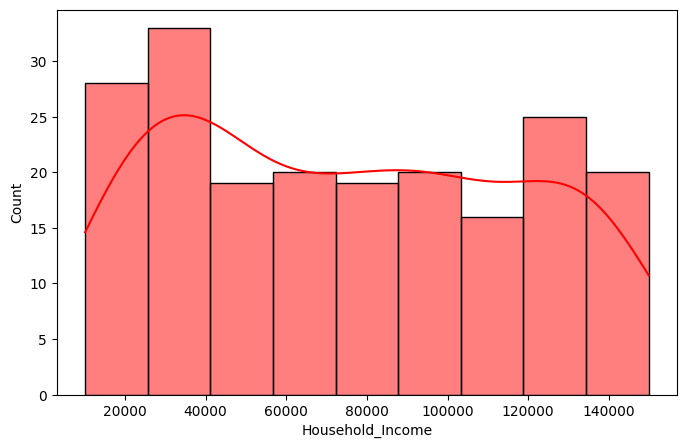

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df['Household_Income'], kde=True, color='red', edgecolor='black')
plt.show()


 #### INSIGHT :- 

##### Most households earn ₹20K–₹40K , Distribution is slightly right-skewed — a few rich households pull the mean up
##### High income inequality — IQR is ₹72,998

### ✅ Question 2 : Fit a Gaussian Normal Distribution Curve 

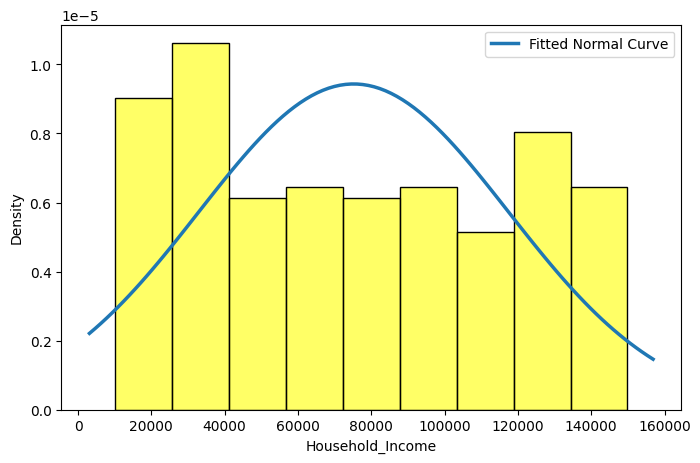

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Household_Income"],
    stat="density",
    color="yellow",
    edgecolor="black",
    alpha=0.6,
)

mu = df["Household_Income"].mean()
sigma = df["Household_Income"].std()

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

p = norm.pdf(x, mu, sigma)
plt.plot(x, p, linewidth=2.5, label="Fitted Normal Curve")

plt.legend()
plt.show()


#### INSIGHT :- 

##### Income is spread evenly, no sharp peak


### ✅ Question 3 : Calculate: Skewness , Kurtosis , of the income data 📈

In [11]:
# Calculate Skewness and Kurtosis
income_skew = df['Household_Income'].skew()
income_kurt = df['Household_Income'].kurt()

print("--- Income Shape Statistics ---")
print(f"Skewness: {income_skew:.2f}")
print(f"Kurtosis: {income_kurt:.2f}")


--- Income Shape Statistics ---
Skewness: 0.14
Kurtosis: -1.27


#### 📌 INSIGHT :- 
#####  Skewness & Kurtosis :- 
##### Skewness = 0.14 → Nearly symmetric, very slight right tail. Between -0.5 and +0.5 is considered approximately normal.
##### Kurtosis = -1.27 → Platykurtic (flatter than normal bell curve). Income is spread evenly, no sharp peak.

### ---------------------------------------------------------------------------------------------------------------

## 📦 7. Data Categorization
### ✅ Question : Use visualization techniques like : Boxplot 📦 , Histogram 📊 to compare household income across : Different education levels 🎓Urban vs Rural areas🌾

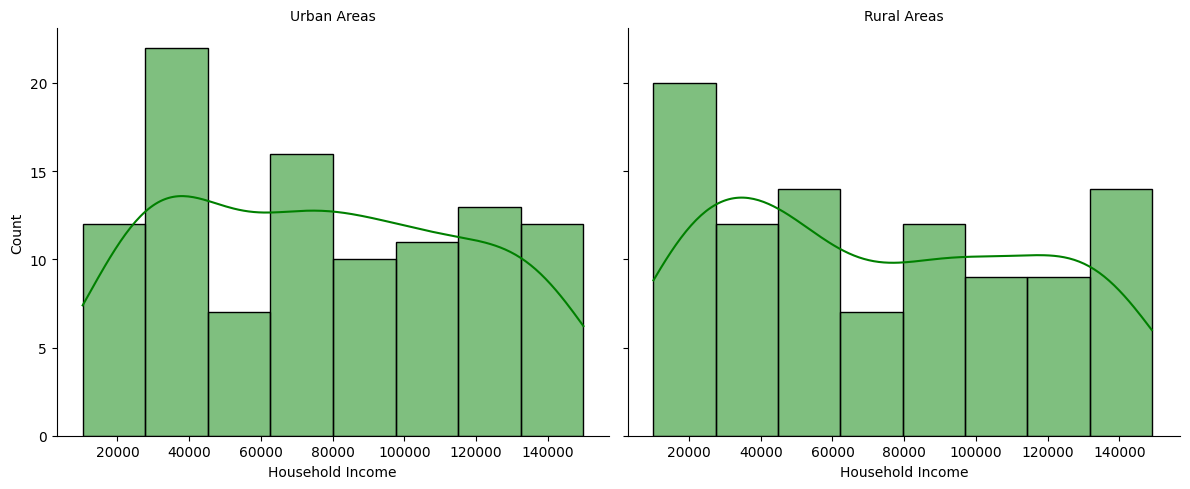

In [12]:
g = sns.FacetGrid(
    df, 
    col="Urban_Rural", 
    height=5, 
    aspect=1.2, 
    hue="Urban_Rural"  
)

g.map_dataframe(
    sns.histplot, 
    x="Household_Income", 
    kde=True, 
    color="green", 
    edgecolor="black"
)

g.set_axis_labels("Household Income", "Count")
g.set_titles("{col_name} Areas")

plt.show()

### ---------------------------------------------------------------------------------------------------------------

### Visualizations
#### Histogram and KDE (Kernel Density Estimation) plot

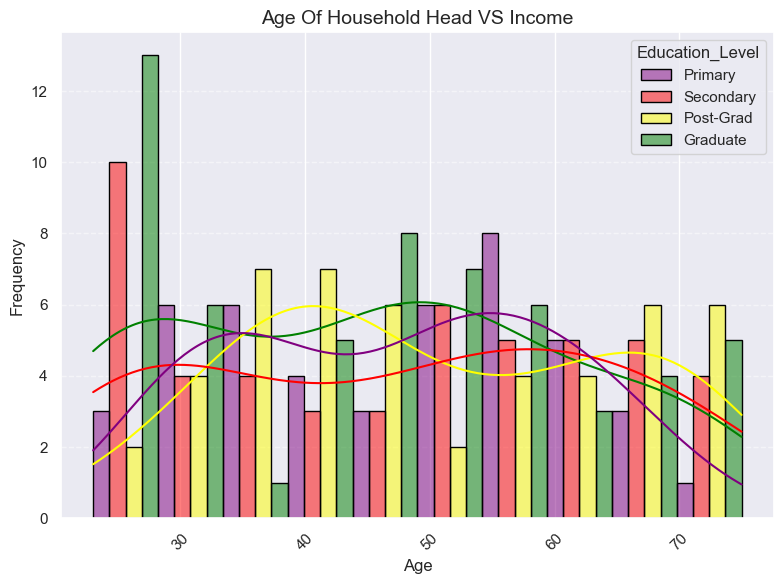

In [13]:
plt.figure(figsize=(8,6))
sns.set_theme(style="darkgrid")
sns.histplot(x=df["Age_of_Household_Head"],hue=df["Education_Level"],multiple="dodge",bins=10,
             kde=True,palette=["purple","red","yellow","green"],edgecolor="black")
plt.title("Age Of Household Head VS Income", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



#### Boxplot comparing Family Size by Education Level

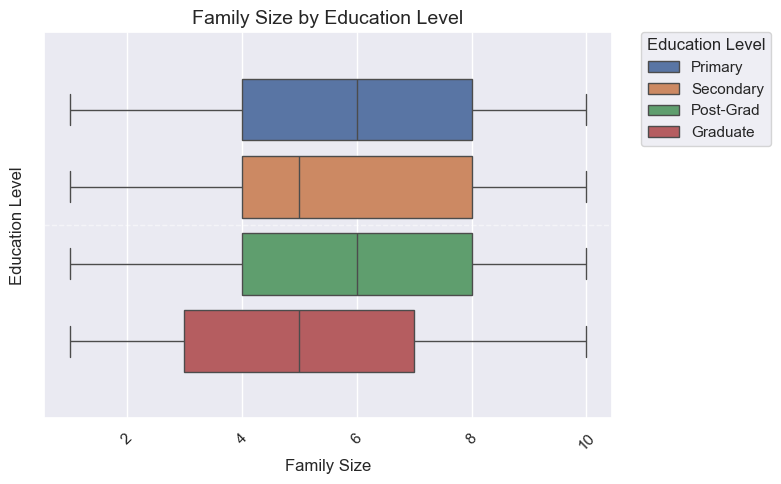

In [14]:
plt.figure(figsize=(8,5))
sns.set_theme(style="darkgrid")
sns.boxplot(data=df,x="Family_Size",hue="Education_Level", gap=0.2)
plt.legend(title="Education Level", bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title("Family Size by Education Level", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xlabel("Family Size")
plt.ylabel("Education Level")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

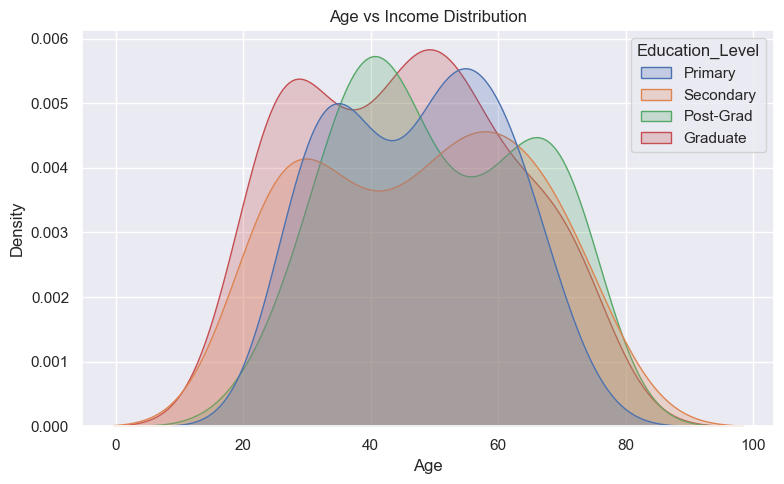

In [13]:
plt.figure(figsize=(8, 5))

sns.kdeplot(data=df, x='Age_of_Household_Head', 
            hue='Education_Level', fill=True)

plt.title("Age vs Income Distribution")
plt.xlabel("Age")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

##### All groups overlap heavily → age alone doesn't determine education level

### ---------------------------------------------------------------------------------------------------------------